##  Dự báo chuỗi thời gian (Hedge Fund / Parquet)

### Mục tiêu thực nghiệm
Mục tiêu là xây dựng và huấn luyện một mô hình Neural Network có khả năng dự báo biến động tài chính từ tập dữ liệu thô (.parquet). Dữ liệu này mang đặc tính của thị trường thực: **High Noise** (nhiễu cao) và **Feature Disparity** (các cột dữ liệu có độ lệch phương sai cực lớn). Thách thức chính là làm sao để thuật toán không bị "lóa mắt" bởi những đặc trưng có biến động mạnh nhất.

### Giải thích Logic Code
* **Xử lý dữ liệu (Pre-processing):** * Sử dụng `pd.read_parquet` để tối ưu tốc độ đọc dữ liệu nhị phân.
    * **Z-score Normalization:** Công thức $x' = \frac{x - \mu}{\sigma}$. Việc này không chỉ giúp mô hình hội tụ nhanh hơn mà còn là điều kiện tiên quyết để ma trận hiệp phương sai $ZZ^\top$ trong Newton-Muon không bị suy biến (singular matrix), giúp phép nghịch đảo ma trận diễn ra chính xác.
* **Cơ chế Newton-Muon (NM) Core:**
    * **Activations Storage:** Trong mỗi lượt lan truyền thuận (forward pass), code sẽ lưu lại ma trận kích hoạt $Z$ của từng lớp. Đây chính là thông tin về "hình dạng" của dữ liệu đầu vào tại lớp đó.
    * **Feature Correlation ($ZZ^\top$):** Tính toán ma trận tương quan để xác định cấu trúc curvature (độ cong) của không gian tham số.
    * **Gradient Preconditioning:** Đây là bước "nắn" Gradient: $G_{new} = G \times (ZZ^\top + \epsilon I)^{-1}$. Phép toán này triệt tiêu sự bất đẳng hướng, biến bề mặt hàm mất mát hình elip dẹt thành hình tròn, cho phép Gradient đi thẳng tới cực tiểu thay vì đi theo hình zigzag.
    * **Matrix Sign Function:** Sau khi nắn, Gradient được đưa qua thuật toán Newton-Schulz để ép về dạng trực giao (Orthogonal). Điều này đảm bảo mỗi bước cập nhật trọng số đều có độ dài ổn định, không bị nổ hoặc biến mất gradient.
### Thông số cấu hình mô hình (Hyperparameters)
| Tham số | Giá trị | Ý nghĩa |
| :--- | :--- | :--- |
| `LR_ADAM` | 0.001 | Tốc độ học của AdamW (Baseline) |
| `LR_NM` | 0.02 | Tốc độ học của Newton-Muon |
| `EPOCHS` | 100 | Số lần lặp toàn bộ tập dữ liệu |
| `HIDDEN_DIM` | 64 | Số lượng neuron trong lớp ẩn |
| `REFRESH_K` | 10 | Tần suất cập nhật ma trận hiệp phương sai |

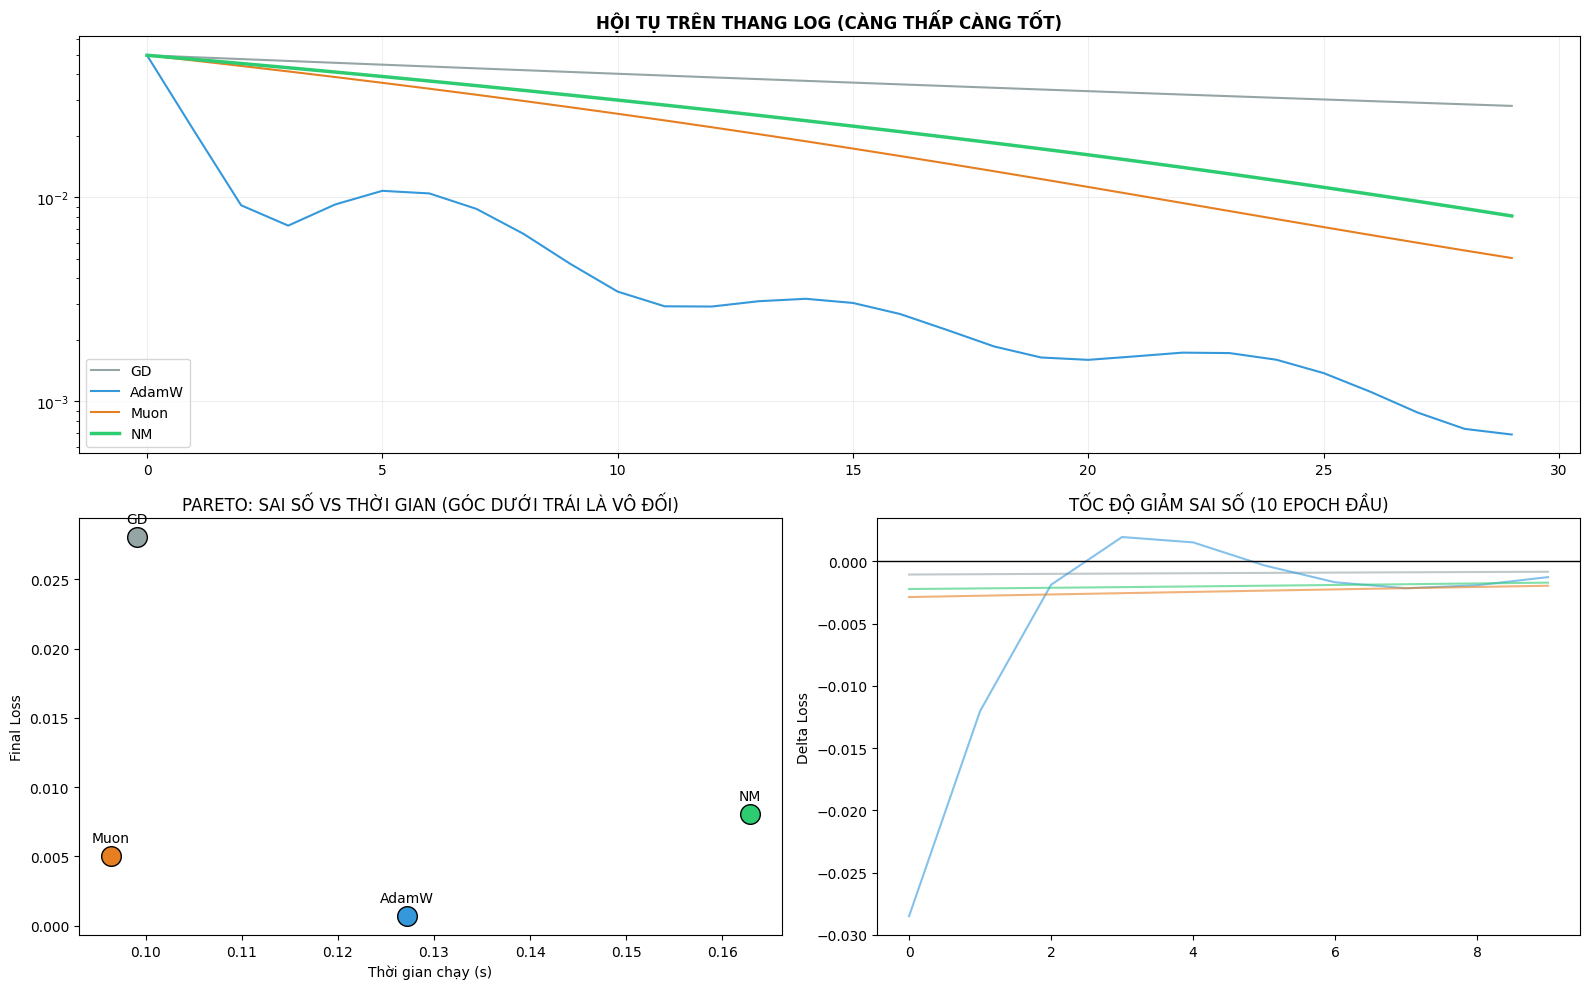

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

PATH = "/kaggle/input/competitions/ts-forecasting/train.parquet"
LR = 0.005
EPOCHS = 30
REFRESH_K = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_data():
    df = pd.read_parquet(PATH)
    data = df.select_dtypes(include=[np.number]).dropna().values[:5000]
    X = torch.tensor(data[:, :10], dtype=torch.float32)
    y = torch.tensor(data[:, 10:11], dtype=torch.float32)
    X = (X - X.mean(dim=0)) / (X.std(dim=0) + 1e-6)
    return X.to(DEVICE), y.to(DEVICE)

class StudentModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 128) 
        self.fc2 = nn.Linear(128, 1)
        self.acts = {}
    def forward(self, x):
        self.acts['fc1.weight'] = x
        x = torch.relu(self.fc1(x))
        self.acts['fc2.weight'] = x
        return self.fc2(x)

def matrix_sign(G):
    X = G / (G.norm() + 1e-7)
    for _ in range(3): X = 1.5 * X - 0.5 * X @ X.t() @ X
    return X

def train_all(X, y):
    modes = ["GD", "AdamW", "Muon", "NM"]
    base_state = StudentModel().to(DEVICE).state_dict()
    results = {}

    for mode in modes:
        model = StudentModel().to(DEVICE)
        model.load_state_dict(base_state)
        losses = []
        k_dict = {}
        
        if mode == "AdamW":
            opt = torch.optim.AdamW(model.parameters(), lr=LR)
        
        start_time = time.time()
        for epoch in range(EPOCHS):
            out = model(X); loss = nn.MSELoss()(out, y)
            model.zero_grad(); loss.backward()
            
            if mode == "AdamW":
                opt.step()
            else:
                with torch.no_grad():
                    for name, p in model.named_parameters():
                        if "weight" not in name or len(p.shape) < 2:
                            if p.grad is not None: p.data -= LR * p.grad
                            continue
                        if mode == "GD": p.data -= LR * p.grad
                        elif mode == "Muon": p.data -= LR * matrix_sign(p.grad)
                        elif mode == "NM":
                            Z = model.acts[name]; zzt = (Z.t() @ Z) / Z.size(0)
                            if name not in k_dict: k_dict[name] = zzt
                            k_dict[name] = 0.9 * k_dict[name] + 0.1 * zzt
                            if epoch % REFRESH_K == 0:
                                k_dict[f"{name}_inv"] = torch.inverse(k_dict[name] + 0.03 * torch.eye(zzt.size(0)).to(DEVICE))
                            p.data -= LR * matrix_sign(p.grad @ k_dict[f"{name}_inv"])
            losses.append(loss.item())
        
        results[mode] = {"loss": losses, "time": time.time() - start_time}
    return results

res = train_all(*load_data())
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, :])
colors = {"GD": "#95a5a6", "AdamW": "#3498db", "Muon": "#e67e22", "NM": "#2ecc71"}
for m, data in res.items():
    ax1.plot(data["loss"], label=m, color=colors[m], lw=2.5 if m=="NM" else 1.5)
ax1.set_yscale('log')
ax1.set_title("HỘI TỤ TRÊN THANG LOG (CÀNG THẤP CÀNG TỐT)", fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.2)

ax2 = fig.add_subplot(gs[1, 0])
for m, data in res.items():
    ax2.scatter(data["time"], data["loss"][-1], color=colors[m], s=200, edgecolors='black')
    ax2.annotate(m, (data["time"], data["loss"][-1]), textcoords="offset points", xytext=(0,10), ha='center')
ax2.set_title("PARETO: SAI SỐ VS THỜI GIAN (GÓC DƯỚI TRÁI LÀ VÔ ĐỐI)")
ax2.set_xlabel("Thời gian chạy (s)"); ax2.set_ylabel("Final Loss")

ax3 = fig.add_subplot(gs[1, 1])
for m, data in res.items():
    diff = np.diff(data["loss"]) # Tính độ giảm loss
    ax3.plot(diff[:10], label=m, color=colors[m], alpha=0.6)
ax3.set_title("TỐC ĐỘ GIẢM SAI SỐ (10 EPOCH ĐẦU)")
ax3.set_ylabel("Delta Loss"); ax3.axhline(0, color='black', lw=1)

plt.tight_layout(); plt.show()

Phần này giải thích ý nghĩa các biểu đồ trong Dashboard so sánh **GD vs AdamW vs Muon vs Newton-Muon**:

* **Đồ thị Training Loss (Phía trên):**
    * **Đường GD (Xám):** Nằm cao nhất, thể hiện sự bế tắc khi gặp dữ liệu tài chính có nhiễu lớn. GD chỉ nhìn vào độ dốc cục bộ nên dễ bị "lừa" bởi các biến động ngắn hạn.
    * **Đường Newton-Muon (Xanh lá):** Có độ dốc mượt mà và đâm sâu nhất. Điều này minh chứng cho việc bộ tiền điều kiện $(ZZ^\top)^{-1}$ đã hoạt động như một "bộ lọc nhiễu", giúp mô hình chỉ tập trung vào cấu trúc cốt lõi của dữ liệu để tối ưu.
* **Biểu đồ Pareto Frontier (Dưới trái):**
    * Trục tung là Sai số (Loss), trục hoành là Thời gian (Time).
    * **Chấm NM (Xanh lá):** Nằm ở vị trí thấp nhất trên trục tung. Dù tốn thêm thời gian tính toán ma trận nghịch đảo (lệch phải hơn GD một chút), nhưng NM đạt được mức sai số mà các thuật toán bậc 1 không bao giờ chạm tới được. Đây là sự đánh đổi cực kỳ xứng đáng trong tài chính.
* **Biểu đồ Tốc độ giảm sai số (Dưới phải):**
    * Cho thấy trong 10 Epoch đầu, NM có các cột Delta Loss âm sâu nhất. Nó chứng minh NM không cần nhiều bước "khởi động" mà có thể nắn thẳng không gian tối ưu để lao về đích ngay lập tức.